# INPUT and define global VARs

In [1]:
import numpy as np
import torch
#import jax
#import jax.numpy as jnp
# mute this since it requires py3.8 and py3.10 env, not default py3.11
#import tensorflow as tf
import iree.compiler
import iree.runtime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# IREE version: candidate-20230815.614

# use DCMAKE_BUILD_TYPE=RelWithDebInfo or Debug and DIREE_ENABLE_ASSERTIONS=ON


REPETITIONS_PER_LAUNCH=7
RAGDOLL_ROOT="../.."
RAGDOLL_WORKSPACE="../../build"
RAGDOLL_WORKLOADS="../../workloads"
CASE_NAME="matmul"

# Input: Matmul (M,K,N) => (1026, 2556, 1026)

In [2]:
!cat {RAGDOLL_WORKLOADS}/common/operators/{CASE_NAME}.mlir
!{RAGDOLL_WORKSPACE}/bin/ragdoll-opt \
    {RAGDOLL_WORKLOADS}/common/operators/{CASE_NAME}.mlir \
    --pass-pipeline="builtin.module(func.func( \
    tosa-to-linalg-named \
))" > {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg
!cat {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg

module {
  func.func @matmul(%arg0: tensor<1026x2556xf32>, %arg1: tensor<2556x1026xf32>) -> tensor<1026x1026xf32> {
    %c0 = arith.constant 0.0 : f32
    %0 = tensor.empty() : tensor<1026x1026xf32>
    %1 = linalg.fill ins(%c0 : f32) outs(%0 : tensor<1026x1026xf32>) -> tensor<1026x1026xf32>
    %2 = linalg.matmul ins(%arg0, %arg1 : tensor<1026x2556xf32>, tensor<2556x1026xf32>) outs(%1 : tensor<1026x1026xf32>) -> tensor<1026x1026xf32>
    return %2 : tensor<1026x1026xf32>
  }
}
module {
  func.func @matmul(%arg0: tensor<1026x2556xf32>, %arg1: tensor<2556x1026xf32>) -> tensor<1026x1026xf32> {
    %cst = arith.constant 0.000000e+00 : f32
    %0 = tensor.empty() : tensor<1026x1026xf32>
    %1 = linalg.fill ins(%cst : f32) outs(%0 : tensor<1026x1026xf32>) -> tensor<1026x1026xf32>
    %2 = linalg.matmul ins(%arg0, %arg1 : tensor<1026x2556xf32>, tensor<2556x1026xf32>) outs(%1 : tensor<1026x1026xf32>) -> tensor<1026x1026xf32>
    return %2 : tensor<1026x1026xf32>
  }
}



# Baseline: Default IREE codegen solution

In [3]:
# release version
!nohup iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg \
-o {RAGDOLL_WORKSPACE}/{CASE_NAME}.rel.vmfb \
--mlir-print-ir-after-all \
--iree-hal-target-backends=cuda \
--iree-hal-cuda-llvm-target-arch=sm_70 > {RAGDOLL_WORKSPACE}/matmul.baseline.rel.dump 2>&1

# benchmark version with repeatance
!nohup iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg \
-o {RAGDOLL_WORKSPACE}/{CASE_NAME}.bench.vmfb \
--mlir-print-ir-after-all \
--iree-hal-target-backends=cuda \
--iree-hal-benchmark-dispatch-repeat-count={REPETITIONS_PER_LAUNCH} \
--iree-hal-cuda-llvm-target-arch=sm_70 > {RAGDOLL_WORKSPACE}/matmul.baseline.bench.dump 2>&1

# DIY: Configure Matmul Kernel with JIT-recipe

In [4]:
!iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg \
--compile-from=input \
--compile-to=executable-sources \
--iree-hal-target-backends=cuda \
--iree-opt-const-eval=1 \
--iree-opt-const-expr-hoisting=1 \
--iree-opt-numeric-precision-reduction=1 \
--iree-hal-cuda-llvm-target-arch=sm_86 > {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-sources
!cat {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-sources

module attributes {hal.device.targets = [#hal.device.target<"cuda", {executable_targets = [#hal.executable.target<"cuda", "cuda-nvptx-fb", {target_arch = "sm_86"}>]}>]} {
  hal.executable private @matmul_dispatch_0 {
    hal.executable.variant public @cuda_nvptx_fb target(<"cuda", "cuda-nvptx-fb", {target_arch = "sm_86"}>) {
      hal.executable.export public @matmul_dispatch_0_matmul_1026x1026x2556_f32 ordinal(0) layout(#hal.pipeline.layout<push_constants = 0, sets = [<0, bindings = [<0, storage_buffer, ReadOnly>, <1, storage_buffer, ReadOnly>, <2, storage_buffer>]>]>) {
      ^bb0(%arg0: !hal.device):
        %x, %y, %z = flow.dispatch.workgroup_count_from_slice 
        hal.return %x, %y, %z : index, index, index
      }
      builtin.module {
        func.func @matmul_dispatch_0_matmul_1026x1026x2556_f32() {
          %cst = arith.constant 0.000000e+00 : f32
          %c0 = arith.constant 0 : index
          %0 = hal.interface.binding.subspan set(0) binding(0) type(storage_buffer) 

In [5]:
!iree-opt {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-sources \
--pass-pipeline="builtin.module(hal.executable(hal.executable.variant(iree-llvmgpu-select-lowering-strategy)))" \
--iree-codegen-llvmgpu-enable-transform-dialect-jit=1 \
--iree-codegen-llvmgpu-enable-transform-dialect-matmul-tensorcore-strategy \
--iree-codegen-llvmgpu-enable-transform-dialect-small-matmul \
--iree-codegen-llvmgpu-enable-transform-dialect-aligned-matmul \
--td-matmul-strategy-blk-sizes=128,64,1 \
--td-matmul-strategy-reduc-size=8 \
--td-matmul-strategy-num-threads=32,2,1 \
--td-matmul-strategy-num-warps=1,2,1 \
--td-matmul-strategy-use-async-copies=false \
--td-matmul-strategy-use-mma-sync=true \
--td-matmul-strategy-pipeline-depth=3 \
 > {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-configurations
!cat {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-configurations

#executable_target_cuda_nvptx_fb = #hal.executable.target<"cuda", "cuda-nvptx-fb", {target_arch = "sm_86"}>
#pipeline_layout = #hal.pipeline.layout<push_constants = 0, sets = [<0, bindings = [<0, storage_buffer, ReadOnly>, <1, storage_buffer, ReadOnly>, <2, storage_buffer>]>]>
#translation = #iree_codegen.translation_info<TransformDialectCodegen>
#device_target_cuda = #hal.device.target<"cuda", {executable_targets = [#executable_target_cuda_nvptx_fb]}>
module attributes {hal.device.targets = [#device_target_cuda]} {
  hal.executable private @matmul_dispatch_0 {
    hal.executable.variant public @cuda_nvptx_fb target(#executable_target_cuda_nvptx_fb) {
      hal.executable.export public @matmul_dispatch_0_matmul_1026x1026x2556_f32 ordinal(0) layout(#pipeline_layout) attributes {translation_info = #translation} {
      ^bb0(%arg0: !hal.device):
        %x, %y, %z = flow.dispatch.workgroup_count_from_slice 
        hal.return %x, %y, %z : index, index, index
      }
      builtin.module {

In [6]:
# one-off version
!iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-configurations \
-o {RAGDOLL_WORKSPACE}/{CASE_NAME}.optimised.rel.vmfb \
--compile-from=executable-configurations \
--iree-hal-target-backends=cuda \
--iree-hal-cuda-llvm-target-arch=sm_86

# inherent repeatance compilation for benchmark
!iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-configurations \
-o {RAGDOLL_WORKSPACE}/{CASE_NAME}.optimised.bench.vmfb \
--compile-from=executable-configurations \
--iree-hal-target-backends=cuda \
--iree-hal-benchmark-dispatch-repeat-count=7 \
--iree-hal-cuda-llvm-target-arch=sm_86

## How to benchmark without python-side overhead interference?
You may need to use specific facilities to avoid encountering python side interference, you may see huge gap between simply run python modules vs run benchmark timing, especially in IREE. IREE's python bindings has considerable bootstrap costs compared to pytorch platform, which put more efforts in this aspects.

In IREE, you can use the benchmark-module tooling for benchmark, use following cmd to understand its usage.
```shell
<PATH TO RAGDOLL ROOT>/codegen_tools_install/iree/bin/iree-benchmark-module --help
```
As an example, you can benchmark iree generated code with following code snippets:
```shell
!<BINARY-DIR>/bin/iree-benchmark-module \
--module=<WORKSPACE>/<CASE-NAME>.benchmark.vmfb.benchmark \
--device=cuda \
--function=matmul \
--input=1026x2556xf32 \
--input=2556x1026xf32 \
--batch_size=7 \
--batch_concurrency=4 \
--benchmark_repetitions=5 \
--benchmark_min_time=1s \
--print_statistics=true
```
You can also embed this benchmarking process in python
```python
workload_fb = "../../build/.matmul.vmfb.benchmark"
config = iree.runtime.system_api.Config("cuda")
vmi = iree.runtime.VmInstance()
with open(workload_fb, 'rb') as file:
    binary_data = file.read()
vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
input_data = ["1026x2556xf32", "2556x1026xf32"]
iree.runtime.benchmark_module(vmm, entry_function="matmul", inputs=input_data, device="cuda", batch_size=REPETITIONS_PER_LAUNCH, benchmark_min_time="1s", print_statistics=True)
```

In pytorch, you can use `torch.utils.benchmark` module for benchmarking, you can try with following code snippets:
```python
import torch.utils.benchmark as benchmark
a = np.random.randn(1026, 2556).astype(np.float32)
b = np.random.randn(2556, 1026).astype(np.float32)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
lhs, rhs = [torch.from_numpy(i) for i in [a, b]]
lhs = lhs.to(device)
rhs = rhs.to(device)
t = benchmark.Timer(
    stmt='torch.matmul(lhs, rhs)',
    globals={'lhs': lhs, 'rhs': rhs}
)

# 运行基准测试并打印结果
result = t.timeit(7)  # 例如，这里我们重复测试 100 次
print(result)
```


In [7]:
# [EXAMPLE] benchmarking IREE-gen kernel by shell

# for rigorious, batch_concurrency should be 1 always, for iteratively launch
!{RAGDOLL_ROOT}/codegen_tools_install/iree/bin/iree-benchmark-module \
--module={RAGDOLL_WORKSPACE}/{CASE_NAME}.bench.vmfb \
--device=cuda \
--function=matmul \
--input=1026x2556xf32 \
--input=2556x1026xf32 \
--batch_size={REPETITIONS_PER_LAUNCH} \
--benchmark_repetitions=5 \
--batch_concurrency=1 \
--benchmark_min_time=1s \
--print_statistics=true

2024-03-14T00:06:23+08:00
Running ../../codegen_tools_install/iree/bin/iree-benchmark-module
Run on (48 X 3800 MHz CPU s)
CPU Caches:
  L1 Data 32 KiB (x24)
  L1 Instruction 32 KiB (x24)
  L2 Unified 512 KiB (x24)
  L3 Unified 16384 KiB (x8)
Load Average: 0.15, 0.08, 0.03
***WARNING*** CPU scaling is enabled, the benchmark real time measurements may be noisy and will incur extra overhead.
--------------------------------------------------------------------------------------------------
Benchmark                                        Time             CPU   Iterations UserCounters...
--------------------------------------------------------------------------------------------------
BM_matmul/process_time/real_time              1.76 ms        0.146 ms          742 items_per_second=566.89/s
BM_matmul/process_time/real_time              1.77 ms        0.147 ms          742 items_per_second=563.41/s
BM_matmul/process_time/real_time              1.77 ms        0.145 ms          742 items_per_

In [8]:
# [EXAMPLE] benchmarking IREE-gen kernel by python

# if you insist measure release version, you may witness considerable 
# python side overheads and bootstrap cost of RT
# workload_fb = RAGDOLL_WORKSPACE+"/"+CASE_NAME+".rel.vmfb"
workload_fb = RAGDOLL_WORKSPACE+"/"+CASE_NAME+".bench.vmfb"
config = iree.runtime.system_api.Config("cuda")
vmi = iree.runtime.VmInstance()
with open(workload_fb, 'rb') as file:
    binary_data = file.read()
vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
input_data = ["1026x2556xf32", "2556x1026xf32"]
iree.runtime.benchmark_module(
    vmm, 
    entry_function="matmul", 
    inputs=input_data, 
    device="cuda", 
    batch_size=REPETITIONS_PER_LAUNCH, 
    benchmark_repetitions=5,
    benchmark_min_time="1s", 
    print_statistics=True
)

/tmp/ipykernel_3082940/282891933.py:11: UserWarning: Making copy of unaligned VmModule buffer. It is recommended to make this deterministic by calling `copy_buffer` to always make a copy or `mmap` to efficiently load from a file. This warning can be silenced by adding `warn_if_copy=False` to `from_buffer`
  vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)


[BenchmarkResult(benchmark_name='BM_matmul/process_time/real_time', time='1.78 ms', cpu_time='0.148 ms', iterations='791', user_counters='items_per_second=562.068/s'),
 BenchmarkResult(benchmark_name='BM_matmul/process_time/real_time', time='1.78 ms', cpu_time='0.149 ms', iterations='791', user_counters='items_per_second=562.52/s'),
 BenchmarkResult(benchmark_name='BM_matmul/process_time/real_time', time='1.78 ms', cpu_time='0.148 ms', iterations='791', user_counters='items_per_second=562.368/s'),
 BenchmarkResult(benchmark_name='BM_matmul/process_time/real_time', time='1.78 ms', cpu_time='0.148 ms', iterations='791', user_counters='items_per_second=562.139/s'),
 BenchmarkResult(benchmark_name='BM_matmul/process_time/real_time', time='1.78 ms', cpu_time='0.149 ms', iterations='791', user_counters='items_per_second=562.635/s'),
 BenchmarkResult(benchmark_name='BM_matmul/process_time/real_time_mean', time='1.78 ms', cpu_time='0.148 ms', iterations='5', user_counters='items_per_second=562

In [9]:
# [EXAMPLE] benchmarking pytorch-gen kernel by python

import torch.utils.benchmark as benchmark
a = np.random.randn(1026, 2556).astype(np.float32)
b = np.random.randn(2556, 1026).astype(np.float32)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
#device = torch.device("cpu:0")
lhs, rhs = [torch.from_numpy(i) for i in [a, b]]
lhs = lhs.to(device)
rhs = rhs.to(device)
t = benchmark.Timer(
    stmt='torch.matmul(lhs, rhs)',
    globals={'lhs': lhs, 'rhs': rhs}
)

# 运行基准测试并打印结果
result = t.timeit(7)  # 例如，这里我们重复测试 100 次
print(result)

torch.matmul(lhs, rhs)
  558.20 us
  1 measurement, 7 runs , 1 thread


## Raw Benchmark Method - by python timers

/tmp/ipykernel_3082940/1623668253.py:10: UserWarning: Making copy of unaligned VmModule buffer. It is recommended to make this deterministic by calling `copy_buffer` to always make a copy or `mmap` to efficiently load from a file. This warning can be silenced by adding `warn_if_copy=False` to `from_buffer`
  vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)


Text(0.5, 0.98, 'Time Cost')

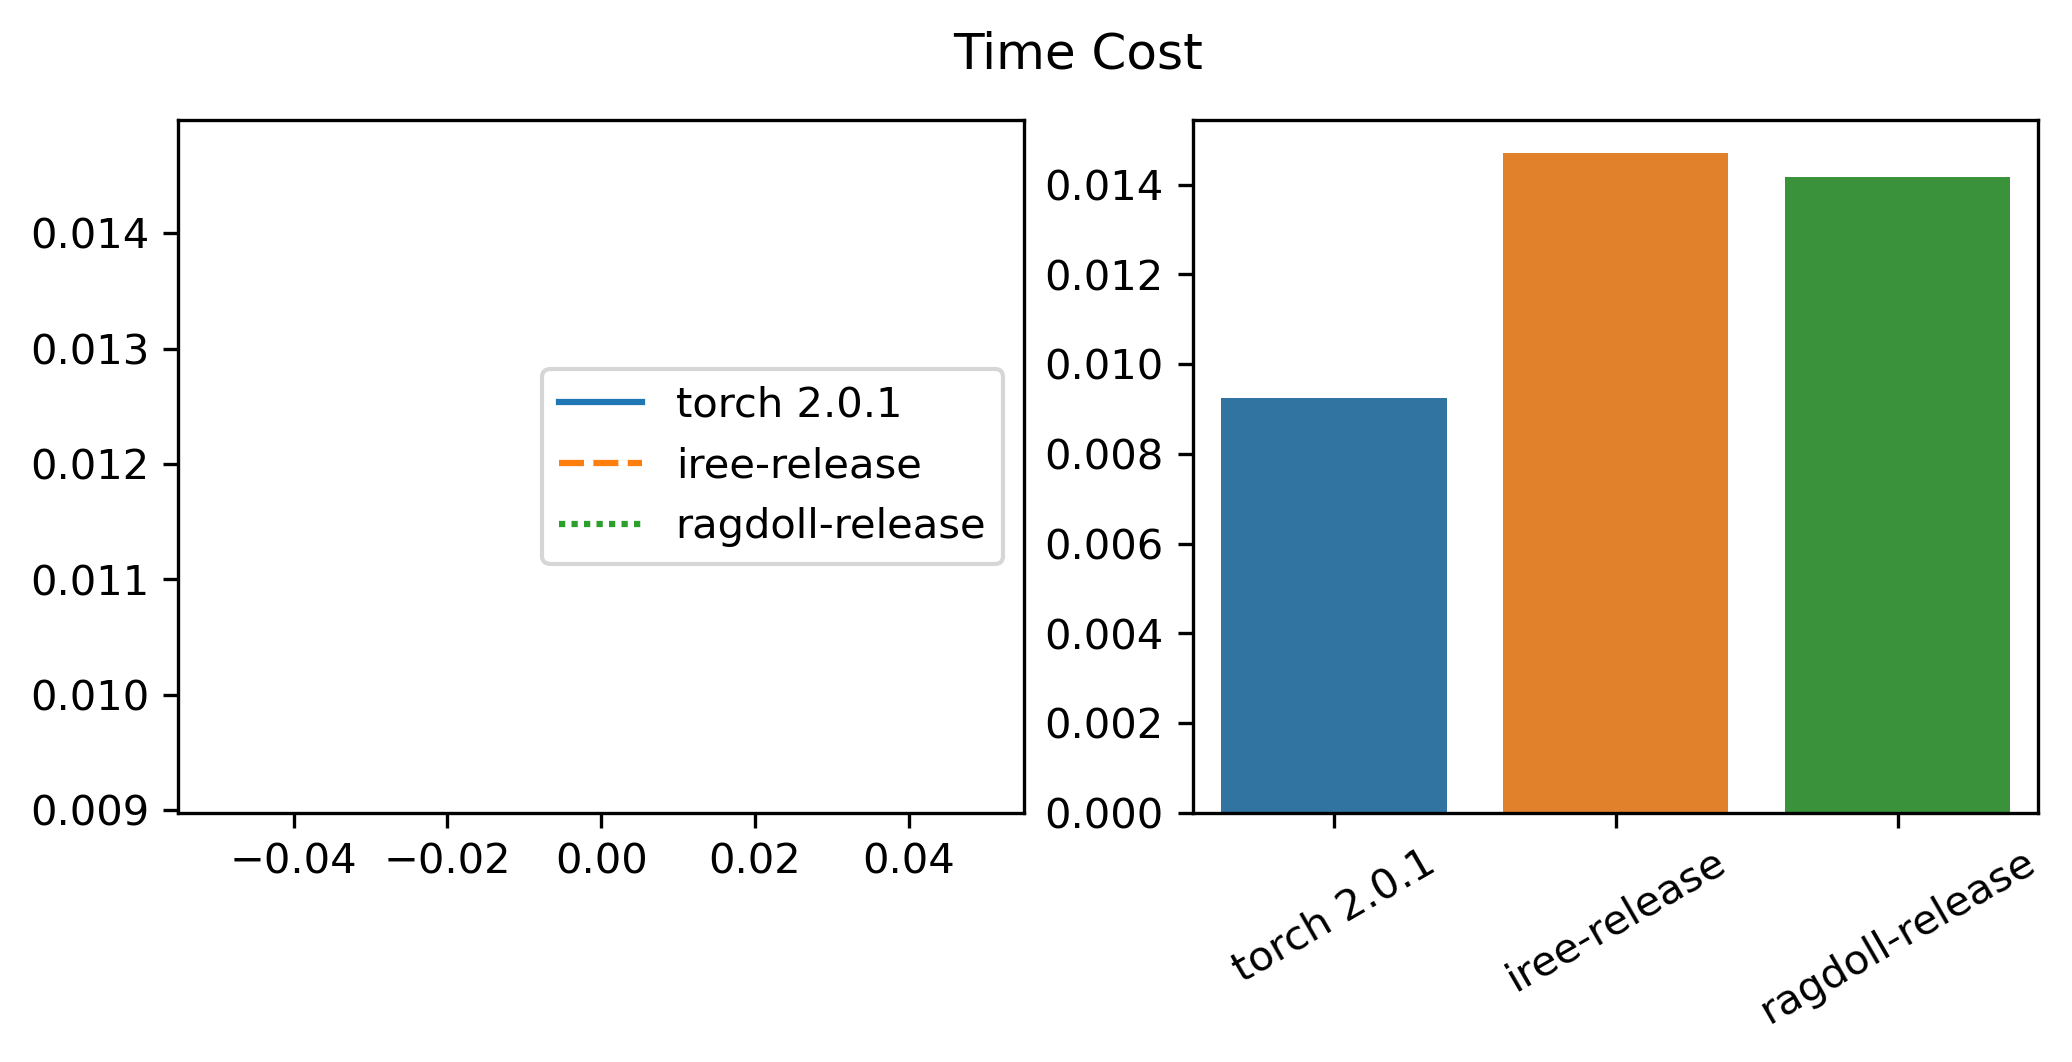

In [10]:
# TODO: move this into ragdoll modules
def iree_load(workload_fb, input_type):
    #CPU
    #config = iree.runtime.system_api.Config("local-task")
    #GPU
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    with open(workload_fb, 'rb') as file:
      binary_data = file.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    vmo = iree.runtime.load_vm_module(vmm, config)
    return vmo
base_iree_module_rel = iree_load(workload_fb=RAGDOLL_WORKSPACE+"/"+CASE_NAME+".rel.vmfb", input_type="auto")
opt_iree_module_rel = iree_load(workload_fb=RAGDOLL_WORKSPACE+"/"+CASE_NAME+".optimised.rel.vmfb", input_type="auto")

from functools import wraps
from time import perf_counter
from collections import namedtuple

TestResult = namedtuple("TestResult", ("res", "forward_timecost"))
TimerResult = namedtuple("TimerResult", ("result", "timecost"))

# this is the python wrapper for system-timer
def timer(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = perf_counter()
        res = func(*args, **kwargs)
        end = perf_counter()
        \
        return TimerResult(res, end - start)
    return wrapper

def torch_benchmark_by_timer(lhs, rhs, repetitions):
    lhs, rhs = [torch.from_numpy(i) for i in [lhs, rhs]]
    #lhs.requires_grad = True
    #rhs.requires_grad = True
    #device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    device = "cpu"
    lhs = lhs.to(device)
    rhs = rhs.to(device)

    @timer
    def forward():
        return torch.matmul(lhs, rhs)
    res, forward_timecost = forward()
    
    return TestResult(res, forward_timecost)
    
def iree_test_rel(lhs, rhs, repetitions):
    @timer
    def forward():
        return base_iree_module_rel["matmul"](lhs, rhs)[0]
    
    res, timecost = forward()
    return TestResult(res, timecost)

def ragdoll_test_rel(lhs, rhs, repetitions):
    @timer
    def forward():
        ret= opt_iree_module_rel["matmul"](lhs, rhs)[0]
        return ret
    res, timecost = forward()
    return TestResult(res, timecost)

def ragdoll_benchmark_by_tool(repetitions):
    workload_fb = RAGDOLL_WORKSPACE+"/"+CASE_NAME+".bench.vmfb"
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    with open(workload_fb, 'rb') as file:
        binary_data = file.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    input_data = ["1026x2556xf32", "2556x1026xf32"]
    
    def forward():
        return iree.runtime.benchmark_module(
            vmm, 
            entry_function="matmul", 
            inputs=input_data, 
            device="cuda", 
            batch_size=REPETITIONS_PER_LAUNCH, 
            benchmark_repetitions=repetitions,
            batch_concurrency=1,
            benchmark_min_time="1s", 
            print_statistics=False
        )
    def ms_to_us(time_str):
        # 移除字符串中的 ' ms'，然后将剩余部分转换为浮点数
        time_in_ms = float(time_str.replace(' ms', ''))
        # 将毫秒转换为微秒
        time_in_us = time_in_ms * 1000
        return time_in_us
    
    bench_result = forward()
    if repetitions > 1:
        forward_timecost = [ms_to_us(measure.time)/1000000.0 for measure in bench_result[0:-3]]
    else:
        forward_timecost = [ms_to_us(bench_result[0].time)/1000000.0]
    results = [0.0 for i in range(repetitions)]
    test_results = [TestResult(*zipped) for zipped in zip(results, forward_timecost)]
    return test_results

def benchmark_entry(repetitions=1):
    lhs_list = [np.random.randn(1026, 2556).astype(np.float32) for _ in range(repetitions)]
    rhs_list = [np.random.randn(2556, 1026).astype(np.float32) for _ in range(repetitions)]
    
    def bench(bench_func, repetitions=1):
        bench_results = []
        for lhs, rhs in zip(lhs_list, rhs_list):
            bench_results.append(bench_func(lhs, rhs, repetitions))
        return bench_results

    
    torch_result = bench(torch_benchmark_by_timer)
    iree_rel = bench(iree_test_rel)
    ragdoll_ref = bench(ragdoll_test_rel)
    #print(iree_rel)
    #ragdoll_bench = ragdoll_benchmark_by_tool(repetitions)
    #print(ragdoll_bench)
    #return torch_result, ragdoll_bench
    return torch_result, iree_rel, ragdoll_ref
    
names = ["torch 2.0.1", "iree-release", "ragdoll-release"]
def get_forward_array(res):
    return np.array(list(map(lambda x : x.forward_timecost, res)))[4:]

results = benchmark_entry(repetitions=5)
forward_line = pd.DataFrame(dict(zip(names, [get_forward_array(res) for res in results])))
forward_bar = pd.DataFrame(dict(zip(names, [[np.mean(get_forward_array(res))] for res in results])))

plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.figsize"] = (3, 3)

fig, (left, right) = plt.subplots(ncols=2, figsize=(8, 3))
sns.lineplot(forward_line, ax=left)
sns.barplot(forward_bar, ax=right)
right.set_xticklabels(right.get_xticklabels(), rotation=30) 
plt.suptitle("Time Cost")

## Apple-to-Apple Benchmark Comparisons
In above case, we use python builtin facilities to benchmark between pytorch, iree and ragdoll
Here, we will present how to get rid of python-side overheads that affect the accuracy of benchmarking

As discussed above we have tools for iree and utils.benchmark module for pytorch

/tmp/ipykernel_3082940/233241362.py:50: UserWarning: Making copy of unaligned VmModule buffer. It is recommended to make this deterministic by calling `copy_buffer` to always make a copy or `mmap` to efficiently load from a file. This warning can be silenced by adding `warn_if_copy=False` to `from_buffer`
  vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)


Text(0.5, 0.98, 'Time Cost')

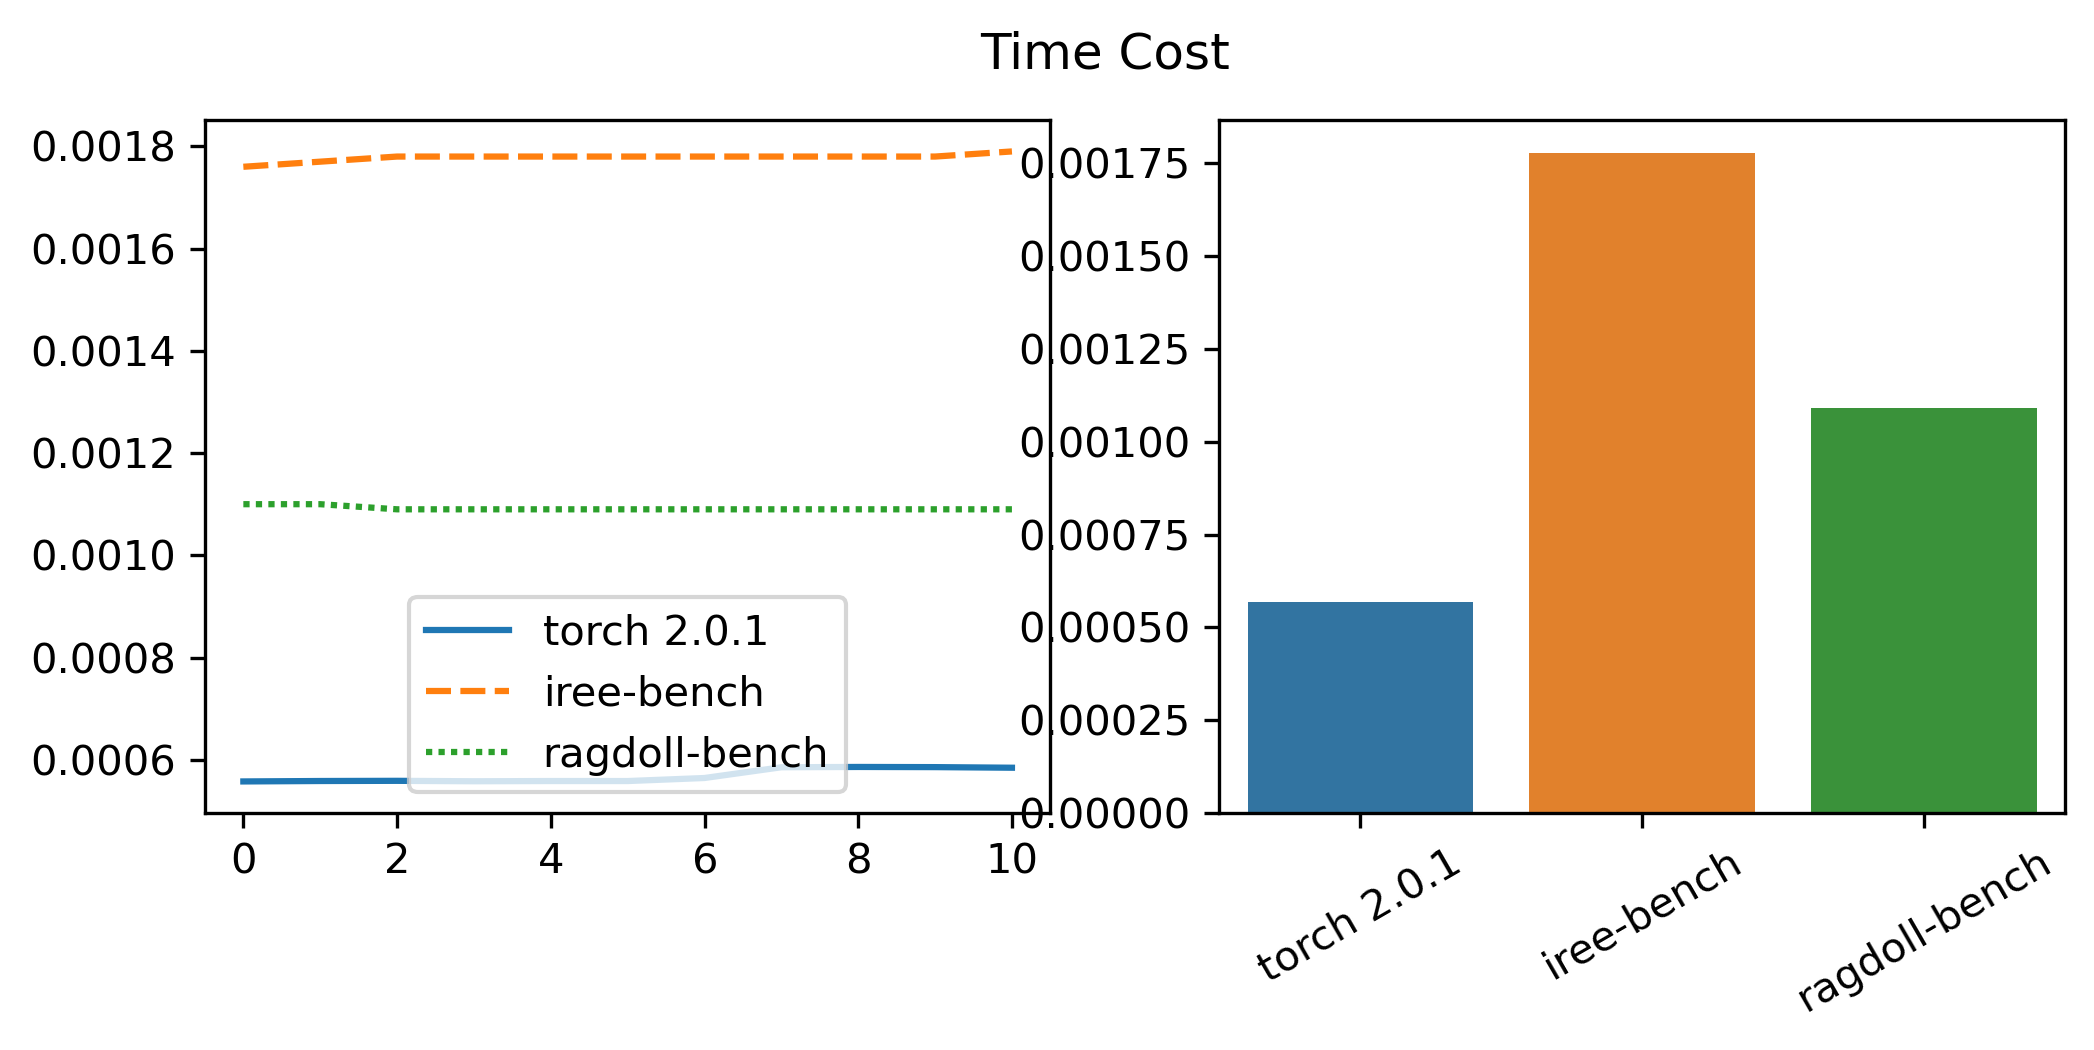

In [11]:
from functools import wraps
from time import perf_counter
from collections import namedtuple

# convert "100 ms" to 100.0
def destringify(time_str, unit='ms'):
    # 移除字符串中的 ' ms'，然后将剩余部分转换为浮点数
    if 'ms' in time_str:
        time_in_us = 1000.0*float(time_str.replace(' ms', ''))
    elif 'us' in time_str:
        time_in_us = float(time_str.replace(' us', ''))
    elif 's' in time_str:
        time_in_us = 1000000.0*float(time_str.replace(' us', ''))
    if unit == 'us':
        return time_in_us
    elif unit == 'ms':
        return time_in_us*0.001
    elif unit == 's':
        return time_in_us*0.000001


def torch_benchmark(repetitions):
    import torch.utils.benchmark as benchmark
    lhs_data = np.random.randn(1026, 2556).astype(np.float32)
    rhs_data = np.random.randn(2556, 1026).astype(np.float32)
    #TODO: move this into ragdoll.utils.get_gpu_device
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    lhs, rhs = [torch.from_numpy(i).to(device) for i in [lhs_data, rhs_data]]
    timer = benchmark.Timer(
        stmt='torch.matmul(lhs, rhs)',
        globals={'lhs': lhs, 'rhs': rhs}
    )
    
    # 运行基准测试并打印结果
    result = []
    for i in range(repetitions):
        result+=timer.timeit(REPETITIONS_PER_LAUNCH).times  # 例如，这里我们重复测试 100 次
    
    return result

def ragdoll_benchmark(repetitions, optimised=False):
    if optimised:
        workload_fb = RAGDOLL_WORKSPACE+"/"+CASE_NAME+".optimised.bench.vmfb"
    else:
        workload_fb = RAGDOLL_WORKSPACE+"/"+CASE_NAME+".bench.vmfb"
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    with open(workload_fb, 'rb') as file:
        binary_data = file.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    input_data = ["1026x2556xf32", "2556x1026xf32"]
    
    def forward():
        return iree.runtime.benchmark_module(
            vmm, 
            entry_function="matmul", 
            inputs=input_data, 
            device="cuda", 
            batch_size=REPETITIONS_PER_LAUNCH, 
            benchmark_repetitions=repetitions,
            batch_concurrency=1,
            benchmark_min_time="1s", 
            print_statistics=False
        )
    
    bench_result = forward()
    if repetitions > 1:
        forward_timecost = [destringify(measure.time, unit='s') for measure in bench_result[0:-4]]
    else:
        forward_timecost = [destringify(bench_result[0].time, unit='s')]
    return forward_timecost

def benchmark_entry(repetitions=1):
    torch_bench = torch_benchmark(repetitions)
    iree_bench = ragdoll_benchmark(repetitions)
    ragdoll_bench = ragdoll_benchmark(repetitions, optimised=True)
    return np.array(torch_bench), np.array(iree_bench), np.array(ragdoll_bench)
    
names = ["torch 2.0.1", "iree-bench", "ragdoll-bench"]
results = benchmark_entry(11)
forward_line = pd.DataFrame(dict(zip(names, [res for res in results])))
forward_bar = pd.DataFrame(dict(zip(names, [[np.mean(res)] for res in results])))

plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.figsize"] = (3, 3)

fig, (left, right) = plt.subplots(ncols=2, figsize=(8, 3))
sns.lineplot(forward_line, ax=left)
sns.barplot(forward_bar, ax=right)
right.set_xticklabels(right.get_xticklabels(), rotation=30) 
plt.suptitle("Time Cost")

## Do it in CPU
to compile CPU version IREE-system kernel, just change 'cuda' to 'llvm-cpu'
just like:
```shell
!iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg \
-o {RAGDOLL_WORKSPACE}/{CASE_NAME}.bench.vmfb.cpu \
--iree-hal-target-backends=llvm-cpu \
--iree-hal-benchmark-dispatch-repeat-count={REPETITIONS_PER_LAUNCH} \
--iree-llvmcpu-debug-symbols=false \
--iree-llvmcpu-target-triple=x86_64-pc-linux-elf
```

to configure optimisation strategy, you have some triggers to adjust:
```shell
--iree-llvmcpu-enable-transform-dialect-jit \
--iree-hal-target-backends=llvm-cpu \
--iree-llvmcpu-target-triple=x86_64-pc-linux-elf \
--iree-llvmcpu-target-cpu-features=+avx2,+fma,+avx \
--iree-llvmcpu-enable-ukernels=all \
--iree-llvmcpu-slp-vectorization \
--iree-llvmcpu-number-of-threads=48 \
--iree-llvmcpu-distribution-size=96 \
```

/tmp/ipykernel_3082940/3152160021.py:61: UserWarning: Making copy of unaligned VmModule buffer. It is recommended to make this deterministic by calling `copy_buffer` to always make a copy or `mmap` to efficiently load from a file. This warning can be silenced by adding `warn_if_copy=False` to `from_buffer`
  vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)


(array([0.05487493, 0.05491718, 0.05492972, 0.0549322 , 0.05493521,
       0.05498531, 0.05494901, 0.05500512, 0.0550276 , 0.05498051,
       0.05497195]), array([0.0671, 0.0672, 0.0673, 0.0673, 0.0674, 0.0674, 0.0674, 0.0674,
       0.0675, 0.0675, 0.0675]), array([0.0674, 0.0674, 0.0674, 0.0674, 0.0674, 0.0674, 0.0674, 0.0674,
       0.0674, 0.0674, 0.0674]))


Text(0.5, 0.98, 'Time Cost')

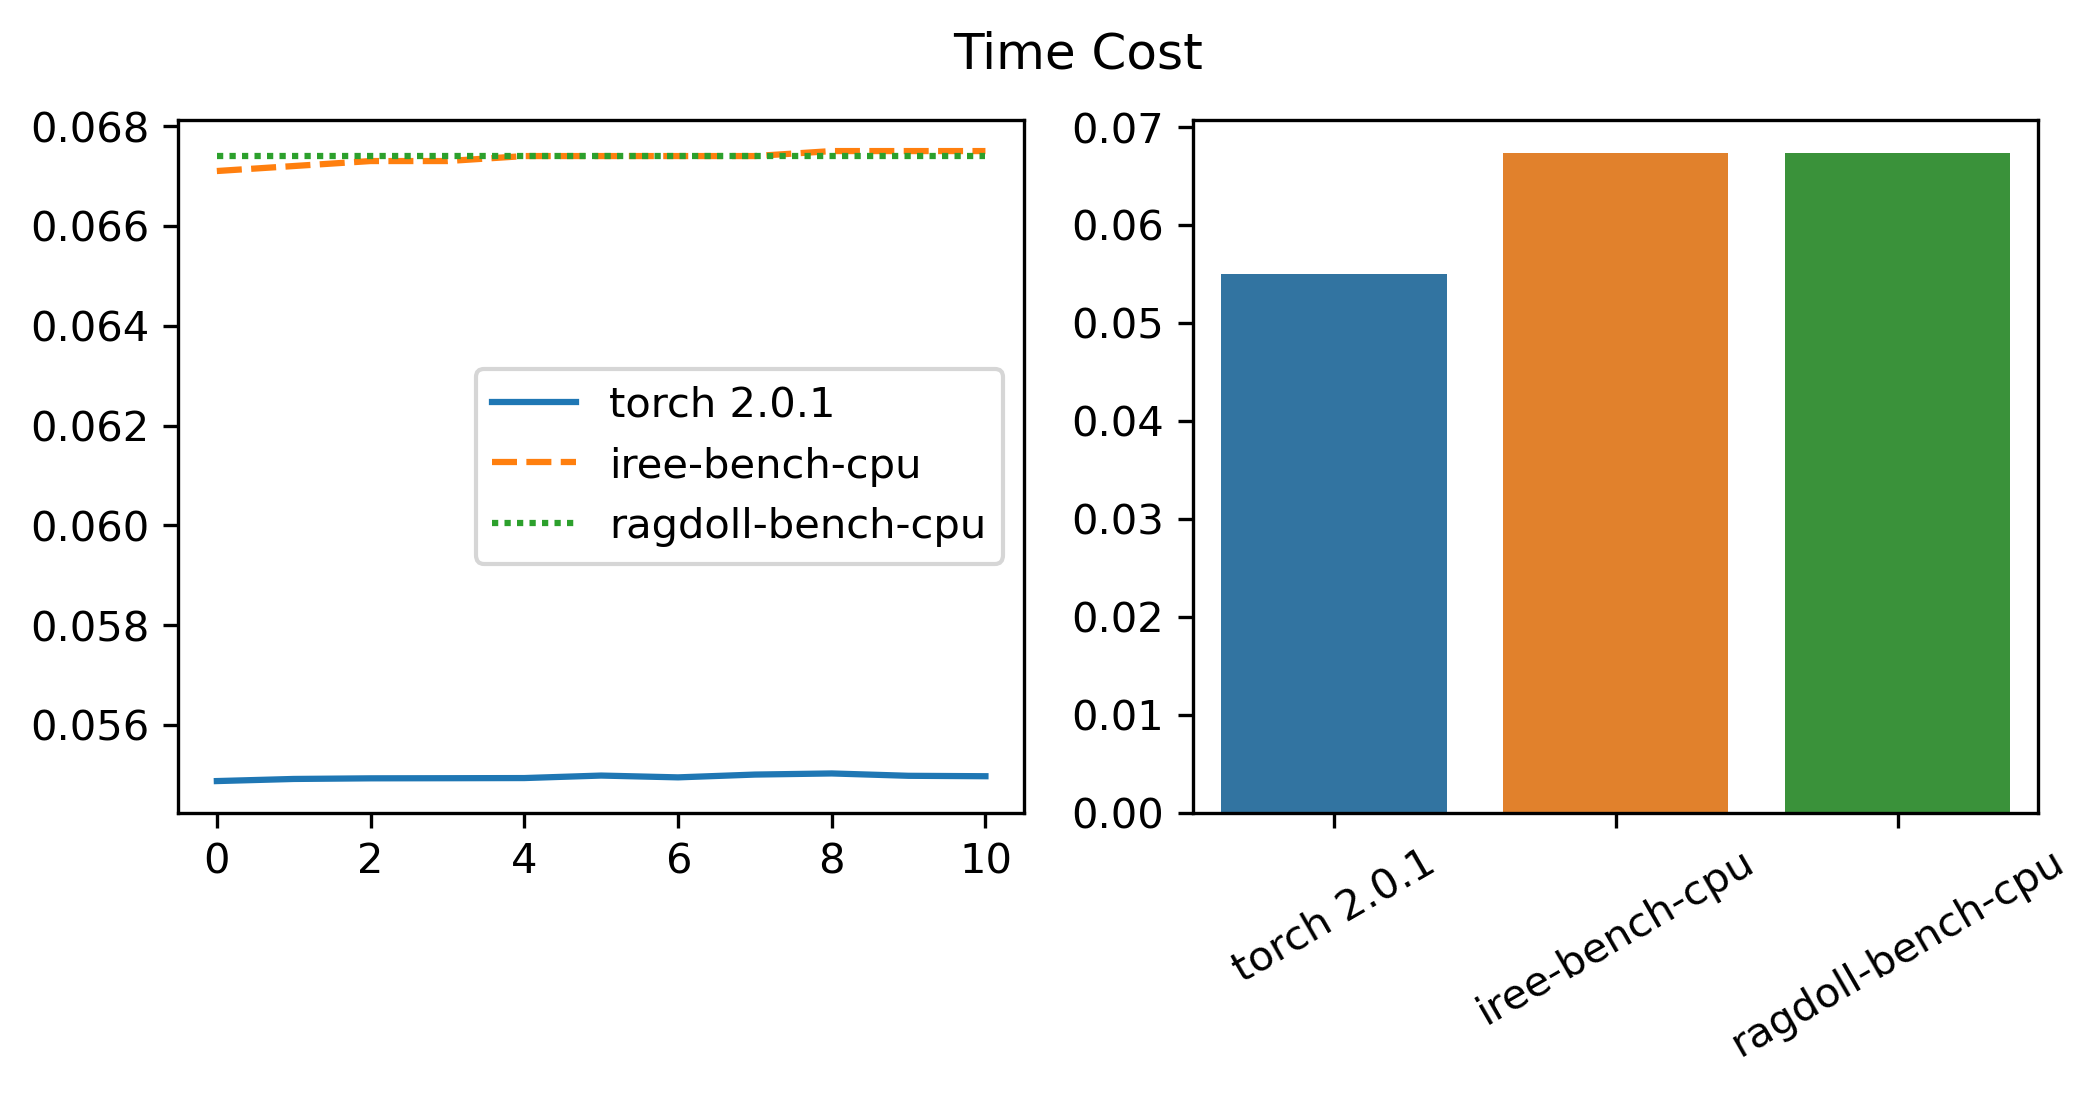

In [25]:
from functools import wraps
from time import perf_counter
from collections import namedtuple

# to compile CPU version IREE-system kernel, just change 'cuda' to 'llvm-cpu'
!iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg \
-o {RAGDOLL_WORKSPACE}/{CASE_NAME}.bench.vmfb.cpu \
--iree-hal-target-backends=llvm-cpu \
--iree-hal-benchmark-dispatch-repeat-count={REPETITIONS_PER_LAUNCH} \
--iree-llvmcpu-debug-symbols=false \
--iree-llvmcpu-target-triple=x86_64-pc-linux-elf

!iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.linalg \
--compile-from=input \
--compile-to=executable-sources \
--iree-hal-target-backends=llvm-cpu \
--iree-opt-const-eval=1 \
--iree-opt-const-expr-hoisting=1 \
--iree-opt-numeric-precision-reduction=1 \
--iree-llvmcpu-target-triple=x86_64-pc-linux-elf > {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-sources.cpu

!iree-opt {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-sources.cpu \
--pass-pipeline="builtin.module(hal.executable(hal.executable.variant(iree-llvmcpu-select-lowering-strategy)))" \
--iree-llvmcpu-enable-transform-dialect-jit=0 \
--iree-hal-target-backends=llvm-cpu \
--iree-llvmcpu-target-triple=x86_64-pc-linux-elf \
--iree-llvmcpu-target-cpu-features=+avx2,+fma,+avx \
--iree-llvmcpu-enable-ukernels=all \
--iree-llvmcpu-slp-vectorization=1 \
--iree-llvmcpu-number-of-threads=48 \
--iree-llvmcpu-distribution-size=96 \
 > {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-configurations.cpu
# --iree-llvmcpu-target-cpu-features=+avx2,+fma,+avx \

# inherent repeatance compilation for benchmark
!iree-compile {RAGDOLL_WORKSPACE}/{CASE_NAME}.mlir.executable-configurations.cpu \
-o {RAGDOLL_WORKSPACE}/{CASE_NAME}.optimised.bench.vmfb.cpu \
--compile-from=executable-configurations \
--iree-hal-target-backends=llvm-cpu \
--iree-llvmcpu-target-triple=x86_64-pc-linux-elf \
--iree-llvmcpu-target-cpu-features=+avx2,+fma,+avx \
--iree-hal-benchmark-dispatch-repeat-count={REPETITIONS_PER_LAUNCH}

# convert "100 ms" to 100.0
def destringify(time_str, unit='ms'):
    # 移除字符串中的 ' ms'，然后将剩余部分转换为浮点数
    if 'ms' in time_str:
        time_in_us = 1000.0*float(time_str.replace(' ms', ''))
    elif 'us' in time_str:
        time_in_us = float(time_str.replace(' us', ''))
    elif 's' in time_str:
        time_in_us = 1000000.0*float(time_str.replace(' us', ''))
    if unit == 'us':
        return time_in_us
    elif unit == 'ms':
        return time_in_us*0.001
    elif unit == 's':
        return time_in_us*0.000001


def torch_benchmark(repetitions):
    import torch.utils.benchmark as benchmark
    lhs_data = np.random.randn(1026, 2556).astype(np.float32)
    rhs_data = np.random.randn(2556, 1026).astype(np.float32)
    #TODO: move this into ragdoll.utils.get_gpu_device
    device = torch.device("cpu")
    lhs, rhs = [torch.from_numpy(i).to(device) for i in [lhs_data, rhs_data]]
    timer = benchmark.Timer(
        stmt='torch.matmul(lhs, rhs)',
        globals={'lhs': lhs, 'rhs': rhs}
    )
    
    # 运行基准测试并打印结果
    result = []
    for i in range(repetitions):
        result+=timer.timeit(REPETITIONS_PER_LAUNCH).times  # 例如，这里我们重复测试 100 次
    
    return result

def ragdoll_benchmark(repetitions, optimised=False):
    if optimised:
        workload_fb = RAGDOLL_WORKSPACE+"/"+CASE_NAME+".optimised.bench.vmfb.cpu"
    else:
        workload_fb = RAGDOLL_WORKSPACE+"/"+CASE_NAME+".bench.vmfb.cpu"
    config = iree.runtime.system_api.Config("local-task")
    vmi = iree.runtime.VmInstance()
    with open(workload_fb, 'rb') as file:
        binary_data = file.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    input_data = ["1026x2556xf32", "2556x1026xf32"]
    
    def forward():
        return iree.runtime.benchmark_module(
            vmm, 
            entry_function="matmul", 
            inputs=input_data, 
            device="local-task", 
            batch_size=REPETITIONS_PER_LAUNCH, 
            benchmark_repetitions=repetitions,
            batch_concurrency=1,
            benchmark_min_time="1s", 
            print_statistics=False
        )
    
    bench_result = forward()
    if repetitions > 1:
        forward_timecost = [destringify(measure.time, unit='s') for measure in bench_result[0:-4]]
    else:
        forward_timecost = [destringify(bench_result[0].time, unit='s')]
    return forward_timecost

def benchmark_entry(repetitions=1):
    torch_bench = torch_benchmark(repetitions)
    iree_bench = ragdoll_benchmark(repetitions)
    ragdoll_bench = ragdoll_benchmark(repetitions, optimised=True)
    return np.array(torch_bench), np.array(iree_bench), np.array(ragdoll_bench)
    
names = ["torch 2.0.1", "iree-bench-cpu", "ragdoll-bench-cpu"]
results = benchmark_entry(11)
print(results)
forward_line = pd.DataFrame(dict(zip(names, [res for res in results])))
forward_bar = pd.DataFrame(dict(zip(names, [[np.mean(res)] for res in results])))

plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.figsize"] = (3, 3)

fig, (left, right) = plt.subplots(ncols=2, figsize=(8, 3))
sns.lineplot(forward_line, ax=left)
sns.barplot(forward_bar, ax=right)
right.set_xticklabels(right.get_xticklabels(), rotation=30) 
plt.suptitle("Time Cost")

## Remark
Above tutorial shown how to handcraft benchmarks for pytorch and IREE platform
However, we wrapped all these utils in ragdoll project, so just use simplified APIs for convenience
in production